### Gaussian Autocorrelation

Let $X = \{x_1, ..., x_N\}$ be a sequence where each $x_n$ is a sample of white noise $\sim \mathcal{N}(0,1)$ and $n$ is the discrete time index.

The autocorrelation function (ACF) of $X$ is given by:
\begin{align*}
\rho_{X}(\tau) &= \mathbb{E}[X(n) X(n - \tau)]\\
&= \delta(\tau)
\end{align*}

where $\delta(\tau)$ is the delta function, defined as:
\begin{align*}
\delta(\tau) &=
\begin{cases}
1 \quad \tau = 0 \\
0 \quad \tau \ne 0
\end{cases}
\end{align*}

Smooth the white noise signal $X(n)$ with a Gaussian kernel:
\begin{align*}
k(\tau; \sigma) = e^{-\frac{\tau^2}{2\sigma^2}}
\end{align*}

Let $X_{\text{smooth}}$ be the convolution of white noise with this kernel:
\begin{align*}
X_{\text{smooth}} = X(n) \ast k(\tau; \sigma)
\end{align*}

The ACF of a convolved signal ($X_{\text{smooth}}$) can be represented as the convolution of the ACFs of the individual components ($X(n)$ and $k(\tau; \sigma$)).

Therefore, the ACF of the smoothed signal is:
\begin{align*}
\rho_{X_{\text{smooth}}}(\tau) &= \mathbb{E}[X_{\text{smooth}}(n) X_{\text{smooth}}(n - \tau)]\\
&= \delta(\tau) \ast k(\tau; \sigma) \ast k(-\tau; \sigma) \\
&= k(\tau; \sqrt{2}\sigma) \\
&= e^{-\frac{\tau^2}{2(2\sigma^2)}}
\end{align*}

since the convolution of two Gaussians is a Gaussian where the variances sum.  

$\therefore$ if the Gaussian kernel has a standard deviation of $\sigma$, its ACF will be a Gaussian function with a standard deviation of $\sqrt{2}\sigma$

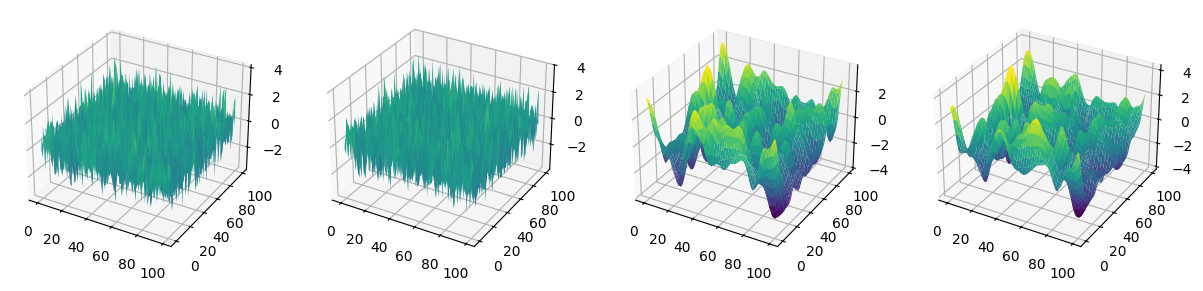

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal, ndimage
from scipy.spatial.distance import pdist, squareform


def _scale_gaussian_variance(std):
    """
    Variance scaling for smoothing with 2D Gaussian
    https://matthew-brett.github.io/teaching/random_fields.html
    """
    limit = std * 5  # \approx 0
    xs = np.arange(-limit, limit + 1)
    ys = xs
    x, y = np.meshgrid(xs, ys)
    gaussian_2d = np.exp(-(x**2 + y**2) / (2 * std**2))
    gaussian_2d = gaussian_2d / gaussian_2d.sum()  # sum = 1
    gaussian_2d_fft = np.fft.fft2(gaussian_2d)  # frequency domain
    gaussian_2d_psd = gaussian_2d_fft * np.conj(gaussian_2d_fft)  # magnitude of frequency domain
    gaussian_2d_cov = np.real(np.fft.ifft2(gaussian_2d_psd))  # covariance matrix
    return gaussian_2d_cov[0, 0]  # variance at center of gaussian kernel


def smooth_img(img, std):
    """Smooth image by applying a Gaussian filter.

    Parameters
    ----------
    img : ndarray of shape (n_pixels, n_pixels)
        The input image.
    std : float
        The standard deviation of the smoothing kernel.

    Returns
    -------
    img_smoothed : ndarray of shape (n_pixels, n_pixels)
        The smoothed image, with the same mean and std of the input image.
    """
    std_scaling_factor = np.sqrt(1 / _scale_gaussian_variance(std))
    img_smoothed = ndimage.gaussian_filter(img, sigma=std, mode="wrap")
    img_smoothed = img_smoothed * std_scaling_factor  # scale variance
    return img_smoothed


# initialize parameters
rng = np.random.default_rng(seed=0)
shape = (100, 100)
fwhm = 8  # n_points in x, y
std = fwhm / (2 * np.sqrt(2 * np.log(2)))  # convert fwhm to std for Gaussian dist.

# simulate img0 and img1 with correlation rho
rho = 0.8
imgs = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=shape)
img0_smoothed = smooth_img(imgs[..., 0], std)
img1_smoothed = smooth_img(imgs[..., 1], std)

# plot img0 and img1
fig, axs = plt.subplots(1, 4, figsize=(15, 4), subplot_kw=dict(projection="3d"))
plot_surface_kwargs = dict(vmin=-std, vmax=std, cmap="viridis", edgecolor="none")

x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))

axs[0].plot_surface(x, y, imgs[..., 0], **plot_surface_kwargs)
axs[1].plot_surface(x, y, imgs[..., 1], **plot_surface_kwargs)
axs[2].plot_surface(x, y, img0_smoothed, **plot_surface_kwargs)
axs[3].plot_surface(x, y, img1_smoothed, **plot_surface_kwargs)

### evaluate correlations btw bivariate random fields

In [2]:
# !!! 10sec runtime !!!
def xcorr(img):
    """Estimate the sample correlation (`rho hat`) between two flattened images (vectors)."""
    img_to_vec = img.reshape(-1, img.shape[-1])
    return (
        (img_to_vec[:, 0] @ img_to_vec[:, 1])
        / (img_to_vec[:, 0].std() * img_to_vec[:, 1].std())
        / img_to_vec.shape[0]
    )


# initialize simulation results
n_simulations = 1000
rhos = [0.0, 0.3, 0.6, 0.9]  # cross-correlation parameters
simulations = {
    f"{rho}_{suffix}": np.zeros(n_simulations) for rho in rhos for suffix in ["img", "img-smoothed"]
}

for rho in rhos:
    for sim in range(n_simulations):
        # generate images
        imgs = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=shape)
        imgs = imgs - imgs.mean(axis=(0, 1))  # mean center
        img0_smoothed = smooth_img(imgs[..., 0], std)
        img1_smoothed = smooth_img(imgs[..., 1], std)
        imgs_smoothed = np.dstack([img0_smoothed, img1_smoothed])

        # estimate rho hats
        rho_hat = xcorr(imgs)
        rho_hat_smoothed = xcorr(imgs_smoothed)

        # save estimates for plotting
        simulations[f"{rho}_img"][sim] = rho_hat
        simulations[f"{rho}_img-smoothed"][sim] = rho_hat_smoothed

Text(0.5, 1.0, '$\\hat{\\rho}_\\text{smoothed}$')

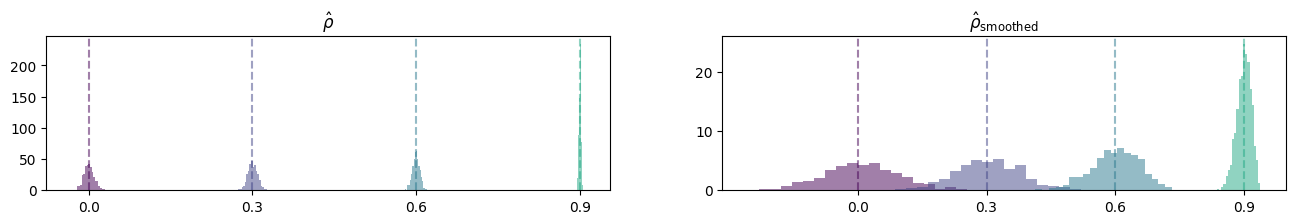

In [3]:
# plot simulations
colors = plt.cm.viridis(np.linspace(0, 1, len(rhos) + 2))
hist_kwargs = dict(bins=20, alpha=0.5, density=True)
vline_kwargs = dict(ls="--", alpha=0.5)

fig, axs = plt.subplots(1, 2, figsize=(16, 2))
for rho, color in zip(rhos, colors):
    axs[0].hist(simulations[f"{rho}_img"], color=color, **hist_kwargs)
    axs[0].axvline(rho, color=color, **vline_kwargs)
    axs[1].hist(simulations[f"{rho}_img-smoothed"], color=color, **hist_kwargs)
    axs[1].axvline(rho, color=color, **vline_kwargs)

axs[0].set_xticks(rhos)
axs[1].set_xticks(rhos)
axs[0].set_title(r"$\hat{\rho}$")
axs[1].set_title(r"$\hat{\rho}_\text{smoothed}$")

### estimate spatial autocorrelation functions

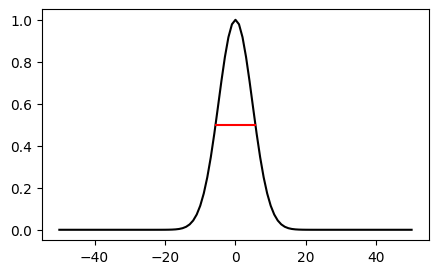

In [4]:
def k(i, j, sigma=1):
    """Gaussian kernel."""
    return np.exp(-(i**2 + j**2) / (2 * sigma**2))


def gaussian_acf(std, shape):
    """Calculate the theoretical autocorrelation function (ACF) of a
    white noise image that has been smoothed with a Gaussian kernel.

    Parameters
    ----------
    std : float
        The standard deviation of the smoothing kernel.
    shape : Tuple of ints
        Shape of the image, e.g. (100, 100).

    Returns
    -------
    array_like `shape`
        ACF of an 2d image smoothed with a Gaussian kernel.
    """
    std_scaling_factor = np.sqrt(1 / _scale_gaussian_variance(std))

    # delta function
    impulse = np.zeros(shape=shape)
    impulse[impulse.shape[0] // 2, impulse.shape[1] // 2] = 1

    # apply Gaussian kernel
    impulse_smoothed = ndimage.gaussian_filter(impulse, sigma=std)
    impulse_smoothed = impulse_smoothed * std_scaling_factor

    # acf
    return signal.convolve(impulse_smoothed, impulse_smoothed, mode="same")


# std of smoothing kernel
fwhm = 8
std = fwhm / (2 * np.sqrt(2 * np.log(2)))

# std of ACF
std_acf = np.sqrt(2) * std
fwhm_acf = std_acf * (2 * np.sqrt(2 * np.log(2)))

# calculate theoretical ACF
acf = gaussian_acf(std, shape=(101, 101))
hm_acf = acf.max() / 2

# plot figure
xs = np.linspace(-50, 50, 101)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(xs, acf[50, :], c="k")
ax.plot([-fwhm_acf / 2, fwhm_acf / 2], [hm_acf, hm_acf], color="r")

In [5]:
# 1
def acf_inner_product(img: np.ndarray, n_lags: int) -> np.ndarray:
    """Estimate spatial ACF iteratively by the inner product.

    Parameters
    ----------
    img : array_like (n_pixels, n_pixels)
        The input image.
    n_lags : int
        The number of lag values for which the ACF should be calculated.

    Returns
    -------
    acf : array_like (n_lags, )
        The ACF for each lag value.
    """
    acf = np.zeros(n_lags)
    for lag in range(1, n_lags + 1):
        img0 = img[:, : -lag or None].flatten()
        img0 -= img0.mean()  # demean img subset
        img1 = img[:, lag:].flatten()
        img1 -= img1.mean()  # demean img subset

        acf[lag - 1] = img0.dot(img1) / np.sum(img**2)
    return acf


# 2
def acf_convolution(img: np.ndarray, n_lags: int) -> np.ndarray:
    """Estimate spatial ACF using symmetric convolution.

    Parameters
    ----------
    img : array_like (n_pixels, n_pixels)
        The input image.
    n_lags : int
        The number of lag values for which the ACF should be calculated.

    Returns
    -------
    acf : array_like (n_lags, )
        The ACF for each lag value.
    """
    img_flipped = np.flipud(np.fliplr(img))  # flip up/down - left/right
    img_conv = signal.convolve(img, img_flipped, mode="same", method="auto")  # direct/fft
    acf = img_conv[: n_lags + 1] / np.sum(img**2)
    center = tuple(map(lambda x: x // 2, img_conv.shape))  # (100,100) -> (50, 50)
    acf = img_conv[center[0], center[1] : center[1] + n_lags + 1] / np.sum(img**2)
    return acf[1:]


# 3
def _acf_distance_weighted(img, weights):
    """calculate autocorrelation for a given weight matrix."""
    img_cov = np.sum(img * signal.convolve(img, weights, mode="same", method="auto"))  # direct/fft
    img_var = np.sum(img**2)
    return img_cov / img_var


def acf_distance_weighted(img: np.ndarray, n_lags: int) -> np.ndarray:
    """Estimate lag-weighted spatial ACF.

    Parameters
    ----------
    img : array_like (n_pixels, n_pixels)
        The input image.
    n_lags : int
        The number of lag values for which the ACF should be calculated.

    Returns
    -------
    acf : array_like (n_lags, )
        The ACF for each lag value.
    """
    acf = np.zeros(n_lags)
    for lag in range(1, n_lags + 1):
        # create weights matrix for given lag
        weights = np.zeros((2 * lag + 1, 2 * lag + 1))
        weights[lag, :] = 1
        weights[:, lag] = 1
        weights[lag, lag] = 0  # central pixel
        weights /= weights.sum()  # normalize

        acf[lag - 1] = _acf_distance_weighted(img, weights)
    return acf


# 4
def acf_sample_pairs(
    img: np.ndarray, n_lags: int, n_samples: int, random_seed: int = 0
) -> np.ndarray:
    """Estimate spatial ACF between pairs of pixels `lag` distance apart.

    Parameters
    ----------
    img : array_like (n_pixels, n_pixels)
        The input image.
    n_lags : int
        The number of lag values for which the ACF should be calculated.
    n_samples : int
        The number of random pixel pairs to sample for each lag value.
    random_seed : int, optional
        Random seed, by default 0.

    Returns
    -------
    acf : array_like (n_lags, )
        The ACF for each lag value.
    """

    acf = np.zeros(n_lags)
    height, width = img.shape
    rng = np.random.default_rng(seed=random_seed)

    img_var = np.var(img)

    for lag in range(1, n_lags + 1):
        pixel_pairs = np.zeros((n_samples, 2))
        idx = 0
        while idx < n_samples:
            i, j = rng.integers(0 + lag, height - lag), rng.integers(0 + lag, width - lag)
            di, dj = rng.choice([[-1, 0], [0, -1], [1, 0], [0, 1]])
            if (di, dj) != (0, 0):
                pixel_pairs[idx] = (img[i, j], img[i + lag * di, j + lag * dj])
                idx += 1

        acf[lag - 1] = np.mean(pixel_pairs[:, 0] * pixel_pairs[:, 1]) / np.var(pixel_pairs)

    return acf

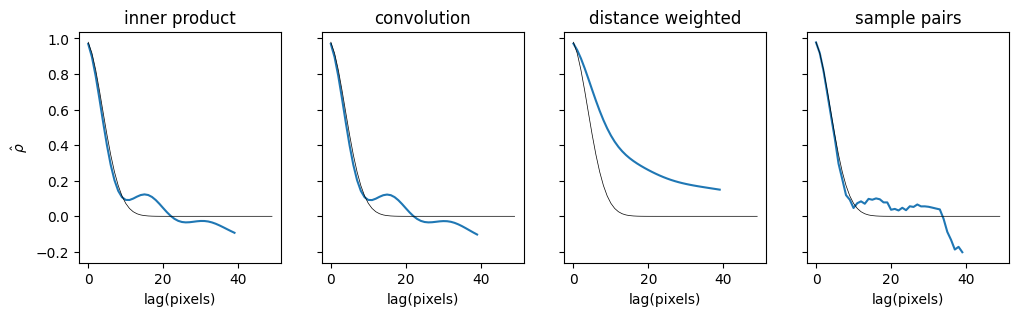

In [6]:
n_lags = 40
img_smoothed = imgs_smoothed[..., 0]
acf_product = acf_inner_product(img_smoothed, n_lags)
acf_conv = acf_convolution(img_smoothed, n_lags)
acf_distance = acf_distance_weighted(img_smoothed, n_lags)
acf_pairs = acf_sample_pairs(img_smoothed, n_lags, n_samples=5000, random_seed=2)

fig, axs = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
axs[0].plot(acf_product)
axs[0].set_title("inner product")
axs[0].set_ylabel(r"$\hat\rho$")
axs[1].plot(acf_conv)
axs[1].set_title("convolution")
axs[2].plot(acf_distance)
axs[2].set_title("distance weighted")
axs[3].plot(acf_pairs)
axs[3].set_title("sample pairs")


for ax in axs:
    ax.plot(acf[50, 51:], c="k", lw=0.5)
    ax.set_xlabel("lag(pixels)")

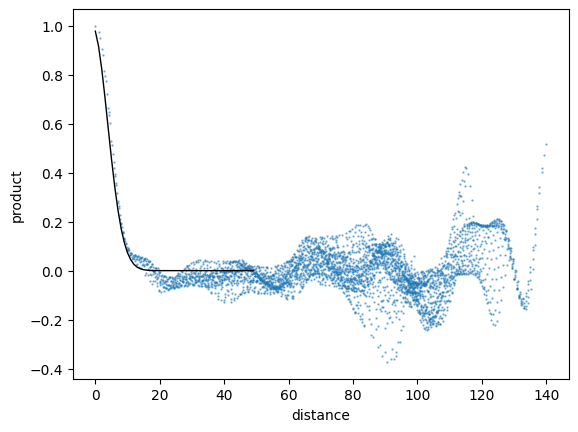

In [7]:
def pairwise_acf(img: np.ndarray) -> np.ndarray:
    """Compute the pairwise autocorrelation function (ACF) for a 2D image.

    Parameters
    ----------
    img : np.ndarray
        The input image.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        - An array of sorted Euclidean distances.
        - An array of corresponding pairwise autocorrelation estimates.
    """
    img_outer_img = np.outer(img, img) / img.var()

    coordinates = np.column_stack(np.where(np.ones_like(img)))
    distances = squareform(pdist(coordinates, metric="euclidean"))

    idx_triu = np.triu_indices_from(distances, k=0)
    idx_distances = np.argsort(distances[idx_triu])

    img_outer_img = img_outer_img[idx_triu][idx_distances]
    distances = distances[idx_triu][idx_distances]
    distances_unique, idx_unique = np.unique(distances, return_inverse=True)

    correlations = np.bincount(idx_unique, weights=img_outer_img) / np.bincount(idx_unique)

    return distances_unique, correlations


fwhm = 8  # n_points in x, y
std = fwhm / (2 * np.sqrt(2 * np.log(2)))  # convert fwhm to std for Gaussian dist.

img = rng.random(size=(150, 150))
img_smoothed = smooth_img(img, std)[25:125, 25:125]  # clip edges
img_smoothed = (img_smoothed - img_smoothed.mean()) / img_smoothed.std()

dist, corrs = pairwise_acf(img_smoothed)
fig, ax = plt.subplots()
ax.scatter(dist, corrs, s=0.5, alpha=0.5)
ax.set_xlabel("distance")
ax.set_ylabel("product")
ax.plot(acf[50, 51:], c="k", lw=1)